# Chapter 16: Thought as Search

Generating another answer can improve the chance that some answer is correct. It does not ensure that the controller can recognize it. A selector that shares the same misconception can confidently choose the wrong candidate while total compute rises.

This notebook separates coverage, selection, cost, and time. You provide several candidate allocations, a correctness construction, and a conditional selector accuracy. The method removes allocations that miss the budget or deadline, then chooses the feasible one with the greatest declared selected success. The changed case replaces independent candidate errors with a shared failure condition. Marginal correctness stays fixed while the benefit of additional sampling changes.

**Outcome:** Separate candidate coverage from actual selector success and choose a feasible allocation.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

Under independent equal candidate correctness p, the probability that at least one of n candidates is correct is C_n=1-(1-p)^n. Under one shared good/bad condition, C_n=p for every positive n. Equal marginals do not distinguish those joint laws.

For n>1, this implementation defines selected success as q C_n, where q is the probability that the selector chooses a correct candidate conditional on one existing. When n=1 the selector is bypassed, so success is p. This convention matters: paying an unreliable selector can make two samples worse than one.

Expense is n c_sample+c_selector and serial latency is n t_sample+t_selector for multiple candidates. Single-candidate allocation omits selector overhead. Feasibility requires both quantities to lie within declared limits. The selected allocation maximizes success, breaking ties toward lower expense. A candidate count with high oracle coverage is not necessarily feasible or operationally best.

## A calculation you can run

Provide candidate counts and all probability, cost, latency, deadline, and dependence inputs. Numeric validation rejects negative resource values, invalid probabilities, and unsupported counts. For each allocation the function calculates coverage, selected success, expense, latency, and feasibility, preserving every row for inspection.

The two figures compare oracle coverage and selector completion by sample count. Their gap is the selector boundary, not an error bar. The selected allocation may skip the visually highest point if it violates a resource constraint. In the changed case keep every scalar fixed and enable shared_error. Predict which row now wins and explain why sampling no longer improves coverage. Export dependence and selector assumptions with the result.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 16
inputs = {'candidate_success': 0.4,
 'selector_accuracy': 0.9,
 'sample_cost': 1,
 'sample_latency': 1,
 'selector_cost': 1,
 'selector_latency': 1,
 'deadline': 6,
 'budget': 6,
 'shared_error': False,
 'sample_counts': [1, 2, 3, 5]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 16: sample-allocation
How many candidates should the controller generate under cost and deadline constraints?
Evidence: constructed teaching example

Calculated quantities:
{
  "selected_allocation": {
    "samples": 5,
    "coverage": 0.92224,
    "selected_success": 0.830016,
    "cost": 6.0,
    "latency": 6.0,
    "feasible": true
  },
  "allocations": [
    {
      "samples": 1,
      "coverage": 0.4,
      "selected_success": 0.4,
      "cost": 1.0,
      "latency": 1.0,
      "feasible": true
    },
    {
      "samples": 2,
      "coverage": 0.64,
      "selected_success": 0.576,
      "cost": 3.0,
      "latency": 3.0,
      "feasible": true
    },
    {
      "samples": 3,
      "coverage": 0.784,
      "selected_success": 0.7056,
      "cost": 4.0,
      "latency": 4.0,
      "feasible": true
    },
    {
      "samples": 5,
      "coverage": 0.92224,
      "selected_success": 0.830016,
      "cost": 6.0,
      "latency": 6.0,
      "feasible": true
    }
  ],
  "sha

Default coverage at n=5 is 1-0.6^5=0.92224. Selected success is 0.9 times that value, or 0.830016. Cost and serial latency are both 6, so this allocation exactly fits the limits and wins among the listed options.

Under shared error, every multiple-candidate row has coverage 0.4 and selected success 0.36. The single candidate bypasses selection and remains at 0.4 with lower expense. It therefore wins. More samples now add cost without improving justified completion, even though each candidate has the same marginal correctness as before.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


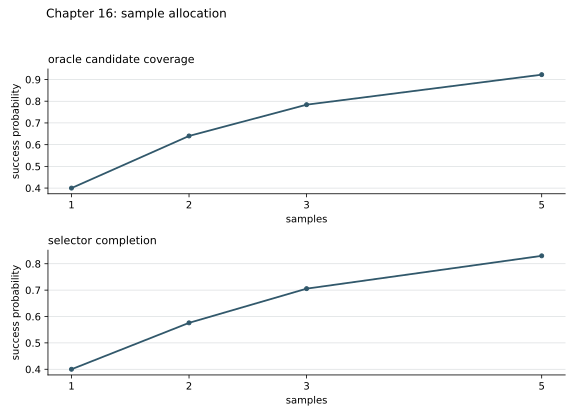

In [3]:
display(SVG(figure_svg(report)))

**Figure 16.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

The formula q C_n is a declared selector model. Real selector accuracy can depend on candidate count, task difficulty, disagreement, or the distribution of wrong answers. A constant q should not be adopted merely because it makes the curve easy to draw. Measure it on held-out candidate sets or state its uncertainty.

Independence is another strong assumption. Repeated samples from one shared flawed context can agree for the wrong reason. The changed construction is deliberately extreme, showing why marginal correctness alone cannot justify the usual saturation curve.

Resource models also need care. Parallel generation changes latency, and a deadline can alter selector behavior. This notebook uses serial time and fixed overhead. If no row is feasible, the selected allocation is unavailable; it does not invent a smaller budget or recommend exceeding a hard limit.

Chapter 16: sample-allocation
How many candidates should the controller generate under cost and deadline constraints?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "selected_allocation": {
    "samples": 1,
    "coverage": 0.4,
    "selected_success": 0.4,
    "cost": 1.0,
    "latency": 1.0,
    "feasible": true
  },
  "allocations": [
    {
      "samples": 1,
      "coverage": 0.4,
      "selected_success": 0.4,
      "cost": 1.0,
      "latency": 1.0,
      "feasible": true
    },
    {
      "samples": 2,
      "coverage": 0.4,
      "selected_success": 0.36,
      "cost": 3.0,
      "latency": 3.0,
      "feasible": true
    },
    {
      "samples": 3,
      "coverage": 0.4,
      "selected_success": 0.36,
      "cost": 4.0,
      "latency": 4.0,
      "feasible": true
    },
    {
      "samples": 5,
      "coverage": 0.4,
      "selected_success": 0.36,
      "cost": 6.0,
      "latency": 6.0,
      "feasible": true
    }
  ],
  "shared_error": t

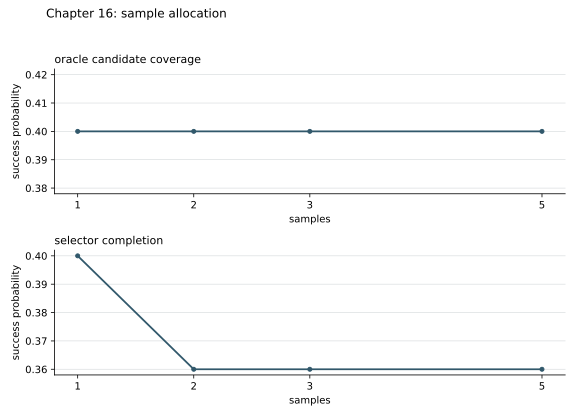

In [4]:
changed_inputs = {'candidate_success': 0.4,
 'selector_accuracy': 0.9,
 'sample_cost': 1,
 'sample_latency': 1,
 'selector_cost': 1,
 'selector_latency': 1,
 'deadline': 6,
 'budget': 6,
 'shared_error': True,
 'sample_counts': [1, 2, 3, 5]}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 16.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer case gives single-candidate success 0.7. Multiple candidates face selector accuracy 0.5 and overhead that makes them miss the three-unit deadline or six-unit budget. The feasible recommendation is one candidate, even though an oracle would see broader coverage in a larger bank.

For local allocation data, distinguish candidate success evidence from selector evidence. Record whether failures are independent, shared, or simply unknown. Unknown dependence calls for a measurement design or sensitivity constructions, not an automatic independence assumption. Use run-level evaluation after executing the chosen allocation to test actual authorized confirmed completion.

In [5]:
transfer_inputs = {'candidate_success': 0.7,
 'selector_accuracy': 0.5,
 'sample_cost': 2,
 'sample_latency': 1,
 'selector_cost': 3,
 'selector_latency': 2,
 'deadline': 3,
 'budget': 6,
 'shared_error': False,
 'sample_counts': [1, 2, 4]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 16: sample-allocation
How many candidates should the controller generate under cost and deadline constraints?
Evidence: constructed transfer example

Calculated quantities:
{
  "selected_allocation": {
    "samples": 1,
    "coverage": 0.7,
    "selected_success": 0.7,
    "cost": 2.0,
    "latency": 1.0,
    "feasible": true
  },
  "allocations": [
    {
      "samples": 1,
      "coverage": 0.7,
      "selected_success": 0.7,
      "cost": 2.0,
      "latency": 1.0,
      "feasible": true
    },
    {
      "samples": 2,
      "coverage": 0.91,
      "selected_success": 0.455,
      "cost": 7.0,
      "latency": 4.0,
      "feasible": false
    },
    {
      "samples": 4,
      "coverage": 0.9919,
      "selected_success": 0.49595,
      "cost": 11.0,
      "latency": 6.0,
      "feasible": false
    }
  ],
  "shared_error": false
}

Interpretation:
Candidate coverage and selected success are different quantities. A correlated shared failure prevents independent-sampling gai

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **candidate_success:** Marginal correctness probability in [0,1].
- **selector_accuracy:** Conditional probability of choosing a correct candidate when one exists.
- **sample_cost:** Nonnegative cost per generated candidate.
- **sample_latency:** Nonnegative serial time per candidate.
- **selector_cost:** Nonnegative selector expense for n>1.
- **selector_latency:** Nonnegative selector time for n>1.
- **deadline:** Nonnegative total time limit.
- **budget:** Nonnegative total expense limit.
- **shared_error:** Exact boolean choosing shared versus independent correctness construction.
- **sample_counts:** Nonempty list of positive integer candidate counts up to 1000.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch16.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 16: sample-allocation
How many candidates should the controller generate under cost and deadline constraints?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "selected_allocation": {
    "samples": 1,
    "coverage": 0.7,
    "selected_success": 0.7,
    "cost": 2.0,
    "latency": 1.0,
    "feasible": true
  },
  "allocations": [
    {
      "samples": 1,
      "coverage": 0.7,
      "selected_success": 0.7,
      "cost": 2.0,
      "latency": 1.0,
      "feasible": true
    },
    {
      "samples": 2,
      "coverage": 0.91,
      "selected_success": 0.455,
      "cost": 7.0,
      "latency": 4.0,
      "feasible": false
    },
    {
      "samples": 4,
      "coverage": 0.9919,
      "selected_success": 0.49595,
      "cost": 11.0,
      "latency": 6.0,
      "feasible": false
    }
  ],
  "shared_error": false
}

Interpretation:
Candidate coverage and selected success are different quantities. A correlated shared failure p

## Questions

1. Compute default n=5 coverage and selection.

2. Why prefer n1 under shared error?

3. What if no allocation is feasible?

Answers: [separate solutions](../solutions/ch16.md). Try the calculation before opening them.

## Summary

Sampling, selection, and feasible completion are separate layers. Independent coverage can rise with candidate count, while shared failures prevent that gain and selector mistakes consume it. Cost and deadlines filter allocations before choice. The default uses five samples, the shared-error case prefers one, and the transfer checks overhead limits. The result is conditional on declared probabilities and serial resource accounting, without turning repeated agreement into correctness evidence.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-16-sample-allocation`](../skills/maa-16-sample-allocation/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 16.1

![Equation 16.1](../assets/math/5e2812ebe7973eccf096.svg)

Equation (16.1) gives the chance that at least one of `k` samples is correct.

One minus the chance that every single sample is wrong.

LaTeX source, preserved for inspection:

```latex
\operatorname{Cov}(k) \;=\; 1 - (1-p)^{k}.
\tag{16.1}
```

### Equation 16.2

![Equation 16.2](../assets/math/9376402bf0c75d691016.svg)

Equation (16.2) gives the chance the returned sample is correct when the selector is blind.

The expected fraction of correct samples among the `k` drawn is `p`, whatever `k` is.

LaTeX source, preserved for inspection:

```latex
\operatorname{Sel}(k) \;=\; \mathrm{E}\!\left[\frac{m}{k}\right] \;=\; p .
\tag{16.2}
```

### Equation 16.3

![Equation 16.3](../assets/math/948f3cacbf230e54c9e1.svg)

Equation (16.3) splits the returned answer's correctness into whether a correct sample was present and whether the selector found it.

Multiply the chance that a correct sample exists among the `k` by the chance the selector ranks one of them top.

LaTeX source, preserved for inspection:

```latex
\operatorname{Sel}(k) \;=\; \operatorname{Cov}(k)\cdot \pi(k) \;+\; \big(1-\operatorname{Cov}(k)\big)\cdot 0 ,
\tag{16.3}
```

### Equation 16.4

![Equation 16.4](../assets/math/54144b0cebaad6ba0716.svg)

Equation (16.4) gives the value of drawing one more sample, before any selector is applied.

The gain from sample number `k` plus one is the chance it is correct times the chance all the previous ones were not.

LaTeX source, preserved for inspection:

```latex
\operatorname{Cov}(k+1) - \operatorname{Cov}(k) \;=\; p\,(1-p)^{k}.
\tag{16.4}
```

### Equation 16.5

![Equation 16.5](../assets/math/65a73d2e35e3d927a4fe.svg)

Equation (16.5) allocates all observed attempt costs across the observed authorized completions.

Add every run's cost, then divide by the number of runs that actually satisfied the declared completion contract.

LaTeX source, preserved for inspection:

```latex
\widehat c_{\mathrm{success}}
=
\frac{\sum_{i=1}^{N}c_i}
{\sum_{i=1}^{N}\mathbf 1\{\text{authorized confirmed completion in run }i\}}.
\tag{16.5}
```